In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

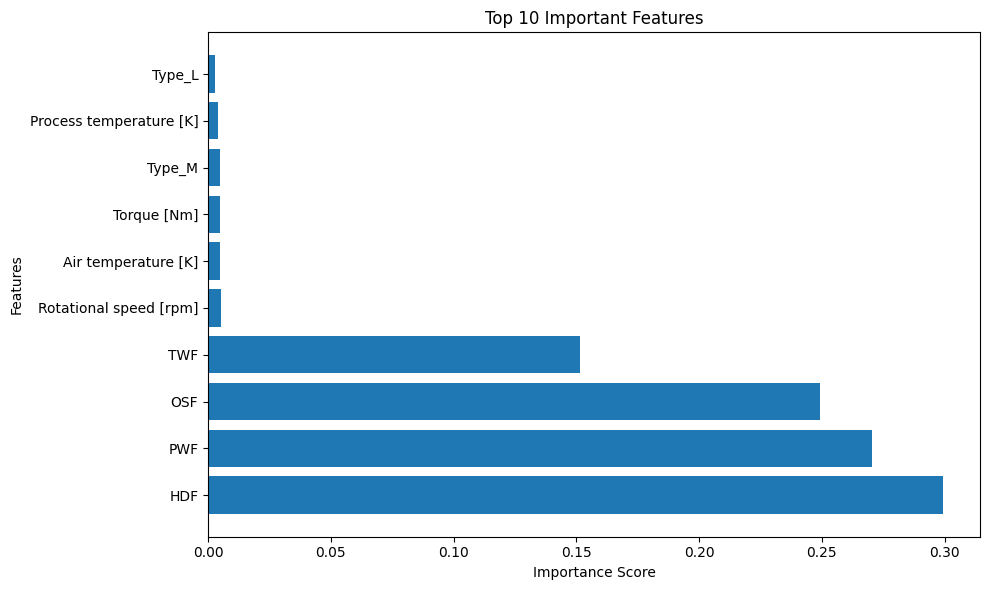

In [2]:
# Load Dataset
df = pd.read_csv("predictive_maintenance.csv")

# Display first rows
print(df.head())

# Remove unnecessary columns
if 'UDI' in df.columns:
    df.drop('UDI', axis=1, inplace=True)

if 'Product ID' in df.columns:
    df.drop('Product ID', axis=1, inplace=True)

# Convert categorical feature
if 'Type' in df.columns:
    df = pd.get_dummies(df, columns=['Type'], drop_first=True)

# Target Variable
target = 'Machine failure'

X = df.drop(target, axis=1)
y = df[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features:")
print(importance.head(10))

# Plot Feature Importance
plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()